Loaded PV_01cm_ramp.csv: 151 samples
Loaded PV_05cm_ramp.csv: 145 samples
Loaded PV_10cm_ramp.csv: 129 samples
Loaded PV_15cm_ramp.csv: 96 samples
Loaded PV_20cm_ramp.csv: 77 samples


,test,samples,max_voltage_V,current_at_max_voltage_mA,max_current_mA,voltage_at_max_current_V,max_power_mW,voltage_at_max_power_V,current_at_max_power_mA
0,01 cm,151,4.591,-0.075,112.075,0.275,396.875,3.985,99.675
1,05 cm,145,4.501,-0.100,111.800,0.280,360.625,4.037,89.250
2,10 cm,129,4.280,-0.075,98.975,0.239,305.625,3.835,79.750
3,15 cm,96,4.202,-0.075,69.925,0.172,214.375,3.584,59.725
4,20 cm,77,4.140,-0.100,55.825,1.024,166.875,3.715,44.875


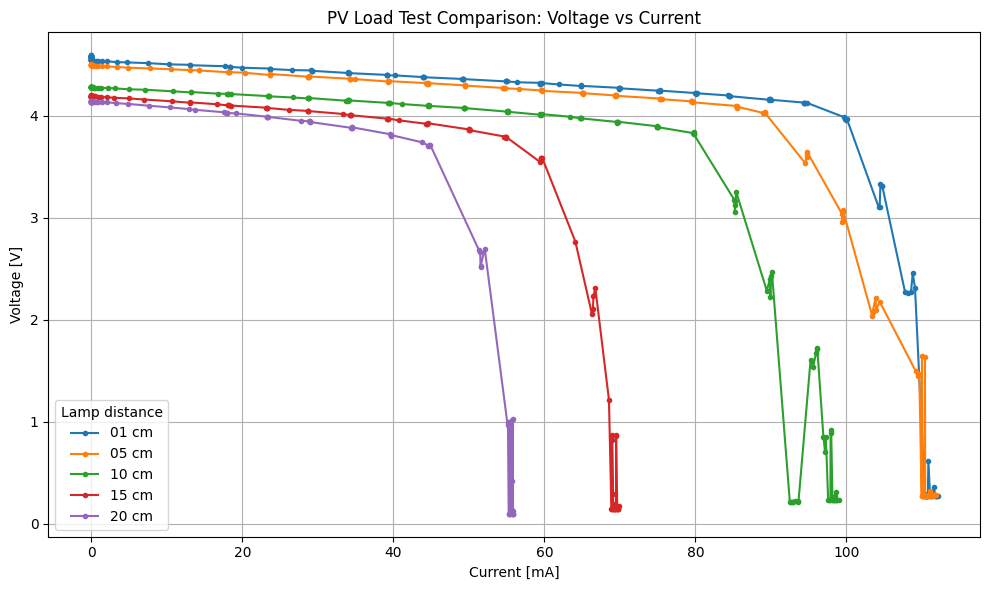

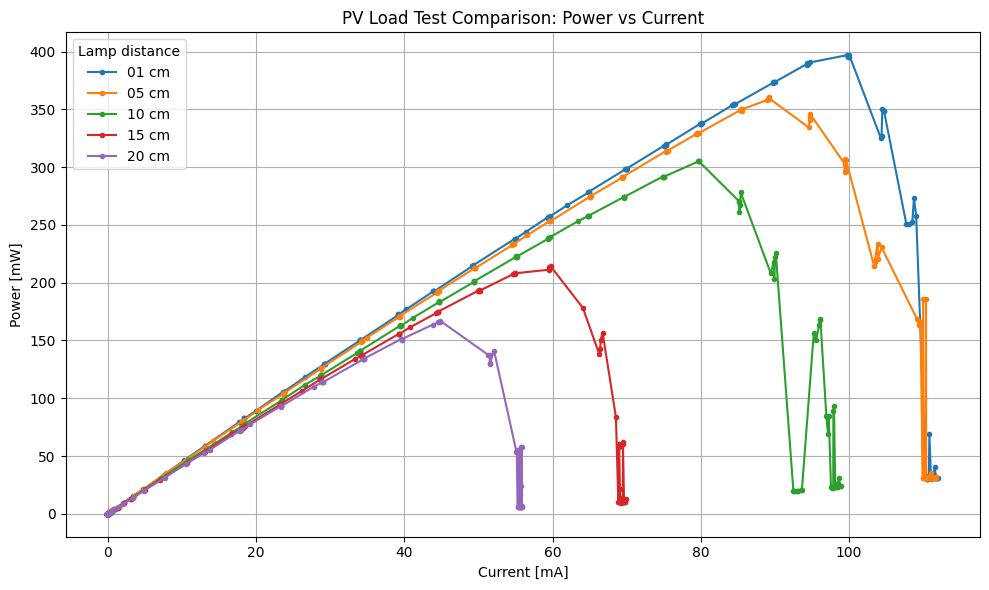

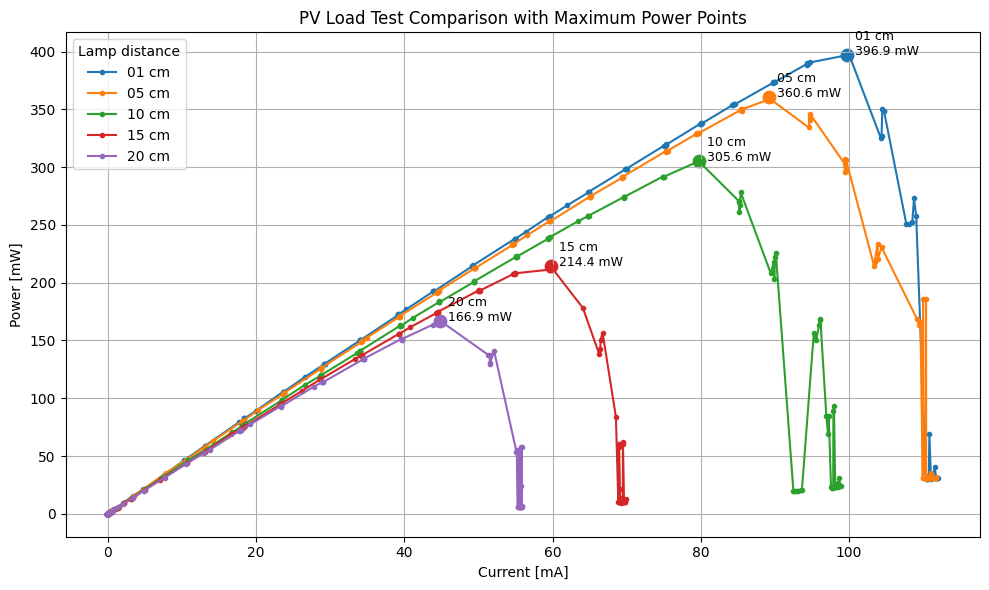

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# User settings
# ============================================================

files = [
    "PV_01cm_ramp.csv",
    "PV_05cm_ramp.csv",
    "PV_10cm_ramp.csv",
    "PV_15cm_ramp.csv",
    "PV_20cm_ramp.csv",
]

data_folder = Path(".")   # Folder containing CSV files

V_COL = "ina3_bus_V"
I_COL = "ina3_current_mA"
P_COL = "ina3_power_mW"


# ============================================================
# Helper functions
# ============================================================

def label_from_filename(filename):
    """
    Converts PV_01cm_ramp.csv to 01 cm.
    """
    name = Path(filename).stem
    distance = name.split("_")[1]
    return distance.replace("cm", " cm")


def load_pv_file(filepath):
    """
    Loads and cleans one PV ramp CSV file.
    """
    df = pd.read_csv(filepath)

    df = df[[V_COL, I_COL, P_COL]].copy()

    df[V_COL] = pd.to_numeric(df[V_COL], errors="coerce")
    df[I_COL] = pd.to_numeric(df[I_COL], errors="coerce")
    df[P_COL] = pd.to_numeric(df[P_COL], errors="coerce")

    df = df.dropna()

    # Sort by current for smoother comparison plots
    df = df.sort_values(I_COL)

    return df


def calculate_summary(df, label):
    """
    Calculates max voltage, current, power, and MPP values.
    """

    idx_pmax = df[P_COL].idxmax()
    idx_vmax = df[V_COL].idxmax()
    idx_imax = df[I_COL].idxmax()

    return {
        "test": label,
        "samples": len(df),

        "max_voltage_V": df.loc[idx_vmax, V_COL],
        "current_at_max_voltage_mA": df.loc[idx_vmax, I_COL],

        "max_current_mA": df.loc[idx_imax, I_COL],
        "voltage_at_max_current_V": df.loc[idx_imax, V_COL],

        "max_power_mW": df.loc[idx_pmax, P_COL],
        "voltage_at_max_power_V": df.loc[idx_pmax, V_COL],
        "current_at_max_power_mA": df.loc[idx_pmax, I_COL],
    }


# ============================================================
# Load all files
# ============================================================

pv_data = {}
summary_rows = []

for file in files:
    filepath = data_folder / file
    label = label_from_filename(file)

    df = load_pv_file(filepath)

    pv_data[label] = df
    summary_rows.append(calculate_summary(df, label))

    print(f"Loaded {file}: {len(df)} samples")


summary_df = pd.DataFrame(summary_rows)

# Round for readability
summary_df = summary_df.round({
    "max_voltage_V": 3,
    "current_at_max_voltage_mA": 3,
    "max_current_mA": 3,
    "voltage_at_max_current_V": 3,
    "max_power_mW": 3,
    "voltage_at_max_power_V": 3,
    "current_at_max_power_mA": 3,
})

display(summary_df)


# ============================================================
# Combined comparison plot: Voltage vs Current
# ============================================================

plt.figure(figsize=(10, 6))

for label, df in pv_data.items():
    plt.plot(
        df[I_COL],
        df[V_COL],
        marker=".",
        linewidth=1.5,
        label=label
    )

plt.xlabel("Current [mA]")
plt.ylabel("Voltage [V]")
plt.title("PV Load Test Comparison: Voltage vs Current")
plt.grid(True)
plt.legend(title="Lamp distance")
plt.tight_layout()
plt.show()


# ============================================================
# Combined comparison plot: Power vs Current
# ============================================================

plt.figure(figsize=(10, 6))

for label, df in pv_data.items():
    plt.plot(
        df[I_COL],
        df[P_COL],
        marker=".",
        linewidth=1.5,
        label=label
    )

plt.xlabel("Current [mA]")
plt.ylabel("Power [mW]")
plt.title("PV Load Test Comparison: Power vs Current")
plt.grid(True)
plt.legend(title="Lamp distance")
plt.tight_layout()
plt.show()


# ============================================================
# Optional: mark maximum power points on Power vs Current plot
# ============================================================

plt.figure(figsize=(10, 6))

for label, df in pv_data.items():
    plt.plot(
        df[I_COL],
        df[P_COL],
        marker=".",
        linewidth=1.5,
        label=label
    )

    idx_pmax = df[P_COL].idxmax()
    i_mpp = df.loc[idx_pmax, I_COL]
    p_mpp = df.loc[idx_pmax, P_COL]

    plt.scatter(i_mpp, p_mpp, s=80)
    plt.text(
        i_mpp,
        p_mpp,
        f"  {label}\n  {p_mpp:.1f} mW",
        fontsize=9
    )

plt.xlabel("Current [mA]")
plt.ylabel("Power [mW]")
plt.title("PV Load Test Comparison with Maximum Power Points")
plt.grid(True)
plt.legend(title="Lamp distance")
plt.tight_layout()
plt.show()